# Data Mining Project: Predicting (i) Customer Churn (ii) Revenue at Risk (iii) Customer Risk Segmentation (iv) short term CLV - using Machine Learning 

## Table of Contents

1. Introduction  
2. Dataset Description  
3. Data Preparation and Feature Engineering  
4. Defining the Churn Variable  
5. Constructing the Modelling Dataset  
6. Machine Learning Models
- 6.1 Preparing Data for Machine Learning
- 6.2 Splitting the Dataset into Training and Testing Sets
- 6.3 k-Nearest Neighbors (kNN) Model 
- 6.4 Naive Bayes Model 
- 6.5 Logistic Regression Model 
7. Model Evaluation & Comparison
8. Revenue at Risk Analysis
9. Predicted Churn
- 9.1 Distribution of Predicted Churn
- 9.2 Rate of Predicted Churn
- 9.3 High-Value Customers at Risk of Churn 
10. Customer Risk Segmentation
11. Estimating Short-Term Customer Lifetime Value at Risk
12. Some Visualisations
- 12.1 Model Performance Comparison
- 12.2 Revenue Exposure by Customer Risk Segment


## 1. Introduction


## Project Objective

The objective of this project is: firstly to be able to predict customer churn from the dataset of B2B Company employing its past sales data, and second, estimate revenue at risk.
Conceptually-speaking, 'customer churn' is the process whereby a customer stops purchasing products from a company. Identifying such customers that are 'likely to churn' allows the company to take proactive actions in order to potentially retain them.
In addition to predicting churn, this project will estimate the Revenue at Risk, which represents the potential loss in revenue if customers predicted to churn do in fact stop purchasing.

This is followed by thirdly, segmentation of the customers based on risk factor, and finally, an estimation of what short-term CLV could like for this dataset, and by extention the company. 

To achieve this, three machine learning models will be trained and evaluated:

- k-Nearest Neighbors (kNN)
- Naive Bayes
- Logistic Regression

Followed by this, all models will be compared based on their predictive performance.

In this document, each step of the process is documentented in markdown, written in code and supported with visuals when needed. 


## 2. Dataset Description

The dataset employed for this project contains B2B sales data, extracted from the company’s ERP system from over a period of approximately 3 years (2023–2025). 

In order to analyze customer purchasing behaviour and identify patterns that may indicate whether a customer is likely to churn, three relevant datasets were selected for this analysis:
- **Customer_Adres_AccMng.xlsx** –> contains customer information, such as customer identifiers, address, etc. 
- **Customer_Turnover per month.xlsx** –> contains monthly revenue generated per customer
- **Order intake per day_Amount and Turnover.xlsx** –> daily order data, such as order amounts


In [8]:
import pandas as pd
import numpy as np

In [9]:
customers = pd.read_excel("data/Customer_Adres_AccMng.xlsx")

monthly_turnover = pd.read_excel("data/Customer_Turnover per month.xlsx")

orders = pd.read_excel("data/Order intake per day_Amount and Turnover.xlsx")


In [10]:
customers.head() 

,Lay-out,Naam,Debiteur,Adresregel 1,Relatiemedewerker,Verkoper,Adresregel 2,Adresregel 3,Postcode,Plaats,Name,Landcode,District
0,DEB2X7MC,2VD Géptervezö és Kereskedö Kft.,15321,Szerelö utca 2,5013,Jakub Hajdon,NaN,NaN,H-2310,Szigetszentmiklós,NaN,HU,NaN
1,DEB2X7MC,7Even SIA,15444,Maza Nometnu street 3-61,5013,Jakub Hajdon,NaN,NaN,LV-1002,Riga,NaN,LV,NaN
2,DEB2X7MC,A Zeta Gomma forniture Industriali S.p.A.,13710,Via Radici in Piano 449/ 1,1009,Rishma Hesen,NaN,www.azetagomma.com,I-41049,Sassuolo,NaN,IT,NaN
3,DEB2X7MC,A&B Schiffs-und Fördertechnik GmbH,13356,Industriestraße 2,1018,Sharon Hoogland,NaN,NaN,D-27628,Bramstedt,Niedersachsen,DE,NI
4,DEB2X7MC,A&D Company d.o.o. Kakanj,15301,Zgosca 60,55,Antoniy Ivanov,NaN,NaN,72240,Kakanj,NaN,BA,NaN


In [11]:
customers.columns 

Index(['Lay-out', 'Naam', 'Debiteur', 'Adresregel 1', 'Relatiemedewerker',
       'Verkoper', 'Adresregel 2', 'Adresregel 3', 'Postcode', 'Plaats',
       'Name', 'Landcode', 'District'],
      dtype='str')

In [12]:
monthly_turnover.head()


,Debiteur,Jaar,Periode,Omzet
0,8000,2024,4,172.80
1,8000,2024,10,232.35
2,8000,2024,11,0.00
3,8000,2025,2,0.00
4,13001,2023,1,6542.50


## 3. Data Preparation and Feature Engineering

## Exploring the Turnover Dataset 

The turnover dataset contains the monthly revenue generated by each customer, wherein each row represents the revenue of a specific customer during a specific month. The dataset provides valuable information about customer purchasing behaviour over time, containing patterns that can be significant when building machine learning models to predict customer churn 
This contains the following key variables:

- **Debiteur** -> Unique customer identifier
- **Jaar** ->Year of the transaction
- **Periode** -> Month of the transaction
- **Omzet** -> Revenue generated by the customer during that month

### Data Preparation: Transforming Transaction Data into Customer-Level Features

After exploring the turnover dataset, the next step in the data mining process is **data preparation**, followed by **feature engineering**. The current dataset records revenue at a **transactional level**, wherein each row represents the revenue generated by a specific customer in a specific month.

However, machine learning algorithms such as **k-Nearest Neighbors (kNN)** and **Naive Bayes** in this case would require a dataset wherein each row represents a single observation. In this project, the observation of interest would be the **customer**.
Therefore, the transactional data available has to be transformed from a **monthly transaction structure** into a **customer-level dataset**. This transformation would firstly, aggregates the revenue data for each customer and second, generates behavioural indicators that summarize purchasing activity over a period of time.

Aggregating the data would eventually allow us to derive meaningful features such as:

- The **total revenue generated by each customer**
- The **number of months in which the customer was active**

These indicators provide for a behavioural representation of customers which would be particularly relevant for identifying patterns associated with **customer churn**. For example, customers who generate lower revenue or purchase less frequently may possess a higher probability of discontinuing their relationship with the company.

In conlcusion, this transformation step is an essential component of the **data preparation phase**, ensuring that the dataset is structured appropriately for training and evaluating machine learning models.


### Feature Engineering: Aggregating Customer Revenue Behaviour

To prepare the dataset for machine learning, the monthly transaction data must be aggregated at the **customer level**. While the original dataset captures revenue per customer per month, predictive models require a dataset where each row represents a single entity.

In this case, the entity of interest is the **customer**, identified by the variable *Debiteur*. Aggregating the transactional data allows us to derive behavioural indicators that summarize purchasing patterns over the observation period.

Two important behavioural features are created:

- **Total Revenue** – the sum of all revenue generated by a customer across the observed time period.
- **Active Months** – the number of months in which the customer generated revenue.

These features capture both the **value** and the **activity level** of each customer. Customers with low total revenue or fewer active months may indicate reduced engagement, which can be a potential signal of future churn.

This step therefore converts the raw transactional data into a **customer-level analytical dataset**, which forms the basis for subsequent modelling.


In [13]:
customer_revenue = monthly_turnover.groupby("Debiteur").agg({
    "Omzet": "sum",
    "Periode": "count"
}).reset_index()

customer_revenue.columns = ["Debiteur", "total_revenue", "active_months"]

customer_revenue.head()


,Debiteur,total_revenue,active_months
0,8000,405.15,4
1,13001,90238.25,9
2,13002,5101.36,1
3,13006,492014.52,28
4,13008,165164.85,21


### Feature Engineering: Average Monthly Revenue

While total revenue provides an indication of the overall monetary value generated by each customer, it does not fully capture the **intensity of purchasing behaviour**.

For example, two customers may generate similar total revenue but differ significantly in their purchasing frequency. One customer might make many small purchases across multiple months, while another might make only a few large transactions.

To capture this behavioural dimension, an additional feature called **Average Monthly Revenue** is created. This metric is calculated by dividing the total revenue generated by a customer by the number of months in which the customer was active.

Average monthly revenue provides insight into the **typical spending level of a customer during an active purchasing period**. This feature can help distinguish between customers who generate steady revenue over time and those who exhibit irregular or declining purchasing behaviour.

Such behavioural indicators are particularly relevant in churn prediction, as customers whose spending intensity decreases may be more likely to discontinue their relationship with the company.


In [14]:
customer_revenue["avg_monthly_revenue"] = (
    customer_revenue["total_revenue"] / customer_revenue["active_months"]
)

customer_revenue.head()


,Debiteur,total_revenue,active_months,avg_monthly_revenue
0,8000,405.15,4,101.287500
1,13001,90238.25,9,10026.472222
2,13002,5101.36,1,5101.360000
3,13006,492014.52,28,17571.947143
4,13008,165164.85,21,7864.992857


### 4. Defining the target variable: Customer Churn

In order to train supervised machine learning models, a **target variable** must be defined. In this project, the objective is to predict **customer churn**, which refers to the situation where a customer stops purchasing products from the company.

Because the dataset does not explicitly contain a churn label, churn must be **inferred from purchasing behaviour**.

A commonly used approach in churn analysis is to define churn based on **customer inactivity over a certain period of time**. Customers who have not generated revenue for an extended period may reasonably be considered to have discontinued their relationship with the company.

For the purposes of this analysis, a customer will be classified as **churned** if they have been inactive for a prolonged period relative to the observation window.

This behavioural definition of churn is frequently applied in transactional datasets where explicit churn labels are unavailable. It allows the modelling process to identify customers whose purchasing activity has significantly declined or stopped.

The churn indicator will therefore be derived from the **recency of customer transactions** within the dataset.


In [15]:
last_purchase = monthly_turnover.groupby("Debiteur").agg({
    "Jaar": "max",
    "Periode": "max"
}).reset_index()

last_purchase.head()


,Debiteur,Jaar,Periode
0,8000,2025,11
1,13001,2025,12
2,13002,2023,2
3,13006,2025,12
4,13008,2025,12


### Measuring Customer Recency

To determine whether a customer has churned, it is necessary to measure **how long it has been since the customer's last purchase**. The dataset records time using separate variables for **year (Jaar)** and **month (Periode)**.

However, calculating inactivity periods requires a single continuous time scale. Therefore, the year and month variables are combined into a **month index**, representing the total number of months elapsed.

This transformation allows the modelling process to calculate the **recency of each customer's last transaction**, which is a widely used behavioural indicator in churn analysis.

Recency measures how recently a customer has interacted with the company. Customers who have not made purchases for a long period are more likely to have discontinued their relationship with the business.

By converting the transaction dates into a continuous time index, it becomes possible to quantify inactivity and subsequently derive the churn indicator.


In [16]:
last_purchase["month_index"] = last_purchase["Jaar"] * 12 + last_purchase["Periode"]

last_purchase.head()


,Debiteur,Jaar,Periode,month_index
0,8000,2025,11,24311
1,13001,2025,12,24312
2,13002,2023,2,24278
3,13006,2025,12,24312
4,13008,2025,12,24312


### Calculating Customer Inactivity

In churn modelling, one of the most informative behavioural indicators is **customer recency**, which measures how long it has been since the customer last interacted with the company.

Using the previously constructed month index, it is now possible to calculate the number of months that have passed since each customer's most recent purchase. This metric is commonly referred to as **customer inactivity**.

Customers who have not generated revenue for an extended period may have discontinued their relationship with the company. Therefore, the duration of inactivity provides a meaningful signal for identifying potential churn behaviour.

To compute this metric, the most recent transaction date observed in the dataset is identified and used as a reference point. The difference between this reference period and each customer's last purchase month yields the **number of months since the customer's last transaction**.

This metric will later be used to derive the **binary churn indicator**, which will serve as the target variable for the machine learning models.


In [17]:
latest_month = last_purchase["month_index"].max()

last_purchase["months_since_last_purchase"] = (
    latest_month - last_purchase["month_index"]
)

last_purchase.head()


,Debiteur,Jaar,Periode,month_index,months_since_last_purchase
0,8000,2025,11,24311,1
1,13001,2025,12,24312,0
2,13002,2023,2,24278,34
3,13006,2025,12,24312,0
4,13008,2025,12,24312,0


### Defining the Binary Churn Indicator

To train supervised machine learning models, the analysis requires a **binary target variable** indicating whether a customer has churned or not.

Since the dataset does not contain an explicit churn label, churn must be **derived from customer behaviour**. In this project, churn is defined based on **customer inactivity**, measured as the number of months since the customer's last recorded purchase.

A commonly used rule in customer analytics is to classify customers as churned if they have not made any purchases for a prolonged period. For the purposes of this analysis, a customer is classified as churned if their inactivity period is **12 months or longer**.

This threshold reflects the assumption that customers who have not generated revenue for an entire year are likely to have discontinued their relationship with the company.

The churn indicator is therefore defined as:

- **1 → Customer has churned**
- **0 → Customer is still active**

This binary variable will serve as the **target variable for the machine learning models** used in the subsequent analysis.


In [18]:
last_purchase["churn"] = (
    last_purchase["months_since_last_purchase"] >= 12
).astype(int)

last_purchase.head()


,Debiteur,Jaar,Periode,month_index,months_since_last_purchase,churn
0,8000,2025,11,24311,1,0
1,13001,2025,12,24312,0,0
2,13002,2023,2,24278,34,1
3,13006,2025,12,24312,0,0
4,13008,2025,12,24312,0,0


### 5. Constructing the Final Modelling Dataset

At this stage, the analysis has produced two sets of information:

1. **Customer behavioural features**, derived from aggregated transaction data  
2. **The churn indicator**, derived from customer inactivity

In order to train machine learning models, these components must be combined into a **single analytical dataset** where each row represents a customer and contains both the explanatory variables (features) and the target variable (churn).

The datasets are therefore merged using the **customer identifier (Debiteur)** as the linking key.

The resulting dataset forms the **final modelling dataset**, which will be used to train and evaluate the machine learning models for churn prediction.


In [19]:
model_data = customer_revenue.merge(
    last_purchase[["Debiteur", "churn"]],
    on="Debiteur",
    how="left"
)

model_data.head()


,Debiteur,total_revenue,active_months,avg_monthly_revenue,churn
0,8000,405.15,4,101.287500,0
1,13001,90238.25,9,10026.472222,0
2,13002,5101.36,1,5101.360000,1
3,13006,492014.52,28,17571.947143,0
4,13008,165164.85,21,7864.992857,0


## 6. Machine Learning Models


### 6.1 Preparing Data for Machine Learning

In order to train supervised machine learning models, the dataset is separated into input features** and a target variable. Separating the dataset into features and target variables allows machine learning algorithms to learn patterns that can distinguish churned customers from those that are still active. 
The explanatory variables (features) represent behavioural characteristics of each customer derived from transaction data:

- **Total Revenue** --> overall monetary value generated by customer
- **Active Months** --> frequency of purchasing activity
- **Average Monthly Revenue** --> typical spending intensity in active periods

The target variable is the binary churn indicator, wherein:

- 1 -->  a churned customer
- 0 --> an active customer




In [20]:
X = model_data[["total_revenue", "active_months", "avg_monthly_revenue"]]

y = model_data["churn"]

X.head()


,total_revenue,active_months,avg_monthly_revenue
0,405.15,4,101.287500
1,90238.25,9,10026.472222
2,5101.36,1,5101.360000
3,492014.52,28,17571.947143
4,165164.85,21,7864.992857


### 6.2 Splitting the Dataset into Training and Testing Sets

In order to evaluate the performance of a machine learning model, the dataset must be divided into training and testing data**.

--> The training dataset allows the model to learn patterns that can distinguish churned customers from active customers
--> The testing dataset is then used to evaluate how well the trained model performs on previously unseen data

This process helps a user ensure that the model does not memorize the training data, but instead learns patterns that can potentially generalize to new customers.

For this analysis, the dataset is split such that approx. 80% of the data is used for training and 20% is reserved for testing (simply reasoning because this would be a commonly used ratio in machine learning applications generally). 

The `train_test_split` function from the 'scikit-learn' library is used to perform this division.


In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape


((450, 3), (113, 3))

### 6.3. k-Nearest Neighbors (kNN) Model

The first machine learning algorithm applied in this analysis is **k-Nearest Neighbors (kNN)**.

kNN is a supervised classification algorithm that predicts the class of an observation based on the classes of its nearest neighbors in the feature space.

In the context of customer churn prediction, the algorithm would classify a customer as either: churned or active, by examining customers with similar behavioral characteristics, such as:
- Total revenue generated
- Number of active purchasing months
- Average monthly revenue, etc. 

The assumption behind this method is that customers with similar purchasing behavior tend to exhibit similar patterns, such as what we are looking for in churn. 

The model uses a parameter 'k' which represents the number of neighboring observations considered when making a prediction; here a value of k = 5 is used, which is commonly applied default for balancing stability and sensitivity.

The model is trained using the training dataset and will later be evaluated on the testing dataset.


In [23]:
from sklearn.neighbors import KNeighborsClassifier


In [24]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [25]:
y_pred_knn = knn_model.predict(X_test)

y_pred_knn[:10]


array([1, 1, 0, 0, 1, 0, 0, 1, 0, 0])

### Model Evaluation: k-Nearest Neighbors

After training the kNN model, its predictive performance must be evaluated using the testing dataset, which contains observations that were not used previously during training. This would yield how unseen data provides an indication of how well the model generalizes to new customers.

Metrics used for evaluation: 
- **Accuracy** -> the proportion of correct predictions
- **Confusion Matrix** -> what types of mistakes a model makes, shows how predictions are distributed between true positives, false positives, true negatives, and false negatives
- **Classification Report** -> Deeper metrics such as precision (when a model predicts in this case churn, how often is it correct), recall (how many actual churners did the model detect successfully), and F1-score (a balance of precision & recall)

Conceptually, these metrics allow for a more comprehensive understanding of the model’s performance in identifying churned customers by answering how well the model detects churned customers, not just whether its predictions are correct overall.


In [26]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [27]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)

accuracy_knn


0.8141592920353983

### Interpretation of kNN Model Performance

The k-Nearest Neighbors model achieved an **accuracy of approximately 81%** on the testing dataset, indicating that the model correctly classified the churn status of the majority of customers based on the selected behavioral features:

-> total revenue
-> number of active purchasing months
-> average monthly revenue

While accuracy provides a useful overview of predictive performance, it does not fully capture how well the model identifies **churned customers specifically**, which is particularly important in churn prediction problems. For this reason, additional evaluation metrics such as the **confusion matrix and classification report** will be examined.


In [28]:
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

conf_matrix_knn


array([[56, 14],
       [ 7, 36]])

In [29]:
print(classification_report(y_test, y_pred_knn))


              precision    recall  f1-score   support

           0       0.89      0.80      0.84        70
           1       0.72      0.84      0.77        43

    accuracy                           0.81       113
   macro avg       0.80      0.82      0.81       113
weighted avg       0.82      0.81      0.82       113



### Interpretation of the Confusion Matrix and Classification Metrics

The confusion matrix provides deeper insight into how the kNN model performs in identifying churned customers.

The model correctly classified **56 active customers** and **36 churned customers**. However, some prediction errors remain. In particular:

- 14 active customers were incorrectly classified as churned (false positives)
- 7 churned customers were incorrectly classified as active (false negatives)

From a business perspective, **false negatives are particularly important**, as these represent customers who are predicted to remain active but actually churn. Missing these customers could result in lost revenue opportunities for retention strategies.

The classification report further indicates that the model achieves a **recall of 0.84 for churned customers**, meaning that 84% of actual churn cases are successfully identified. This suggests that the model performs reasonably well in detecting customers who are at risk of leaving.

Nevertheless, additional models will be tested to determine whether predictive performance can be improved.


### 6.4. Naive Bayes Model

The second machine learning algorithm used in this analysis is **Naive Bayes**.

Naive Bayes is a probabilistic classification algorithm based on **Bayes' Theorem**, which assumes that the input features are conditionally independent given the target variable.

Despite this simplifying assumption, Naive Bayes often performs well in classification tasks, particularly when dealing with structured numerical data.

In this churn prediction problem, the model will use the same behavioral features:

- total revenue
- number of active purchasing months
- average monthly revenue

The model will be trained on the training dataset and evaluated using the same testing dataset, allowing for a direct comparison with the kNN model.


In [30]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [31]:
y_pred_nb = nb_model.predict(X_test)

y_pred_nb[:10]


array([1, 1, 0, 1, 1, 1, 1, 1, 1, 1])

In [32]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)

accuracy_nb


0.4336283185840708

In [33]:
confusion_matrix(y_test, y_pred_nb)


array([[ 6, 64],
       [ 0, 43]])

In [34]:
print(classification_report(y_test, y_pred_nb))


              precision    recall  f1-score   support

           0       1.00      0.09      0.16        70
           1       0.40      1.00      0.57        43

    accuracy                           0.43       113
   macro avg       0.70      0.54      0.37       113
weighted avg       0.77      0.43      0.32       113



### Interpretation of the Naive Bayes Model

The Naive Bayes model achieved an **accuracy of approximately 43%**, which is significantly lower than the performance observed with the k-Nearest Neighbors model.

Analysis of the confusion matrix reveals that the model correctly identified **all churned customers**, resulting in a recall score of **1.00 for the churn class**. However, the model incorrectly classified the majority of active customers as churned, leading to a very low recall score for the active class (0.09).

This indicates that the Naive Bayes model exhibits a strong bias toward predicting churn. While detecting all churned customers may appear beneficial, the large number of false positives would lead to inefficient allocation of retention resources in a real business context.

The poor performance of the Naive Bayes model may be attributed to the **strong independence assumption** underlying the algorithm. In this dataset, the behavioral features (total revenue, active purchasing months, and average monthly revenue) are likely correlated, which violates the assumptions of the Naive Bayes classifier.

For this reason, additional models such as **Logistic Regression** will be evaluated to determine whether a more suitable predictive model can be identified.


### 6.5. Logistic Regression Model

The third machine learning model applied in this analysis is **Logistic Regression**, a widely used classification algorithm for binary prediction problems.

Logistic Regression models the probability that a given observation belongs to a particular class. In this case, the model estimates the probability that a customer will **churn** based on the behavioral features derived from the dataset.

Unlike k-Nearest Neighbors, which relies on distance between observations, Logistic Regression estimates model parameters that describe the relationship between the independent variables and the probability of churn.

Because of its interpretability and strong theoretical foundation, Logistic Regression is commonly used in **customer analytics, credit risk modelling, and churn prediction tasks**.


In [35]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [36]:
y_pred_log = log_model.predict(X_test)

y_pred_log[:10]


array([1, 1, 0, 0, 1, 0, 0, 1, 0, 0])

In [37]:
accuracy_log = accuracy_score(y_test, y_pred_log)

accuracy_log


0.7787610619469026

In [38]:
confusion_matrix(y_test, y_pred_log)


array([[53, 17],
       [ 8, 35]])

In [39]:
print(classification_report(y_test, y_pred_log))


              precision    recall  f1-score   support

           0       0.87      0.76      0.81        70
           1       0.67      0.81      0.74        43

    accuracy                           0.78       113
   macro avg       0.77      0.79      0.77       113
weighted avg       0.79      0.78      0.78       113



### Interpretation of the Logistic Regression Model

The Logistic Regression model achieved an **accuracy of approximately 78%**, which is slightly lower than the performance of the k-Nearest Neighbors model but significantly better than the Naive Bayes model.

The confusion matrix indicates that the model correctly classified **53 active customers** and **35 churned customers**. Some prediction errors remain, including false positives (active customers predicted as churn) and false negatives (churned customers predicted as active).

The classification report shows that the model achieved a **recall score of 0.81 for churned customers**, meaning that approximately 81% of customers who actually churned were correctly identified.

Overall, the Logistic Regression model demonstrates balanced predictive performance and provides an interpretable baseline model for churn prediction. However, when comparing model accuracy and recall metrics, the **k-Nearest Neighbors model appears to provide the strongest overall performance for this dataset.**


### 7. Model Evaluation & Comparison

The three models and their respective accuracy compared: 
kNN: 0.81
Naive Bayes: 0.43
Logistic Regression: 0.78

This is also supported by Visualisations in section 12.1. 

Based on the results, the **k-Nearest Neighbors model achieves the most predictive accuracy**. The Naive Bayes model translates rather poorly in comparison, which is likely due to the strong independence assumptions- as the model assumes that all input features are independent of each other)- that possibly do not hold for the behavioral features derived in this dataset.


Therefore, for further steps the **kNN model will be used for further analysis**, estimating the potential revenue at risk associated with customers predicted to churn.



# 8. Revenue at Risk Analysis

In [40]:
model_data["predicted_churn"] = knn_model.predict(X)


In [41]:
revenue_at_risk = model_data[model_data["predicted_churn"] == 1]["total_revenue"].sum()

revenue_at_risk


np.float64(1787403.3199999998)

### Interpretation of Revenue at Risk

The analysis thus estimates that approximately **1.79 million in revenue** can be associated with customers predicted to churn by the k-Nearest Neighbors model.This value represents the **potential revenue exposure** if these customers were to discontinue their purchasing relationship with the company.

From a business perspective, this insight is valuable for it allows the organization to prioritize its efforts in customer retention toward customer accounts that present the greatest financial risk. Rather than applying generic retention strategies across the entire customer base, the company can focus resources on customers identified by the model as primarily high risk. 

## 9. Predicted Churn 

In [42]:
model_data["predicted_churn"].value_counts()


predicted_churn
0    353
1    210
Name: count, dtype: int64

### 9.1 Distribution of Predicted Churn

The results indicate that **210 customers are predicted to churn**, while **353 customers are predicted to remain active**.




In [43]:
churn_rate = model_data["predicted_churn"].mean()

churn_rate


np.float64(0.37300177619893427)

## 9.2 Predicted Churn Rate

The predicted churn rate is the proportion of customers that the model classifies as likely to churn. In this analysis, 37% of customers are predicted to churn. 

Monitoring this metric potentially provides an overview of the overall stability of a customer base and can help organizations evaluate the urgency of implementing retention strategies.


In [44]:
high_value_churn = model_data[model_data["predicted_churn"] == 1] \
    .sort_values("total_revenue", ascending=False)

high_value_churn.head(10)


,Debiteur,total_revenue,active_months,avg_monthly_revenue,churn,predicted_churn
439,15140,47329.40,2,23664.700000,1,1
312,14219,46585.00,2,23292.500000,1,1
239,13960,45741.00,6,7623.500000,1,1
536,15419,44702.99,7,6386.141429,0,1
520,15400,43797.20,4,10949.300000,1,1
59,13180,43548.71,8,5443.588750,1,1
335,14273,42808.50,5,8561.700000,1,1
111,13383,42114.60,7,6016.371429,0,1
347,14309,40537.34,5,8107.468000,1,1
462,15231,39594.00,4,9898.500000,0,1


## 9.3 High-Value Customers at Risk of Churn 

To further comprehend the finanacial result of churn analysis, customers predicted to churn were reviewed according to their historical revenue contribution in the past.

The table above presents the **highest-value customers who are at risk of churn**.

These customers could be prioritized for retention initiatives because losing them would have a disproportionately siginificant financial implication for the company.


### 10. Customer Risk Segmentation

In [45]:
model_data["risk_segment"] = "Low"

median_revenue = model_data["total_revenue"].median()

model_data.loc[
    (model_data["predicted_churn"] == 1) & (model_data["total_revenue"] >= median_revenue),
    "risk_segment"
] = "High Value - High Risk"

model_data.loc[
    (model_data["predicted_churn"] == 1) & (model_data["total_revenue"] < median_revenue),
    "risk_segment"
] = "Low Value - High Risk"

model_data.loc[
    (model_data["predicted_churn"] == 0) & (model_data["total_revenue"] >= median_revenue),
    "risk_segment"
] = "High Value - Low Risk"

model_data.loc[
    (model_data["predicted_churn"] == 0) & (model_data["total_revenue"] < median_revenue),
    "risk_segment"
] = "Low Value - Low Risk"

model_data["risk_segment"].value_counts()


risk_segment
High Value - Low Risk     264
Low Value - High Risk     192
Low Value - Low Risk       89
High Value - High Risk     18
Name: count, dtype: int64


The model results were also used to segment customers into risk categories based on their predicted churn status and revenue contribution in the past. Thus customers were grouped into four strategic segments:

1. High Value - High Risk
2. High Value - Low Risk
3. Low Value - High Risk
4. Low Value - Low Risk

This segmentation allows the company maximizing the impact of its customer relationship management strategies with focus. 


### 11. Estimating Short-Term Customer Lifetime Value at Risk

In [46]:
model_data["estimated_clv_risk"] = (
    model_data["avg_monthly_revenue"] * 12 * model_data["predicted_churn"]
)

model_data[model_data["predicted_churn"] == 1].sort_values(
    "estimated_clv_risk", ascending=False
).head(10)


,Debiteur,total_revenue,active_months,avg_monthly_revenue,churn,predicted_churn,risk_segment,estimated_clv_risk
460,15223,33240.00,1,33240.000,1,1,High Value - High Risk,398880.00
439,15140,47329.40,2,23664.700,1,1,High Value - High Risk,283976.40
312,14219,46585.00,2,23292.500,1,1,High Value - High Risk,279510.00
542,15426,28684.00,2,14342.000,0,1,High Value - High Risk,172104.00
468,15252,37826.61,3,12608.870,0,1,High Value - High Risk,151306.44
551,15436,23853.57,2,11926.785,0,1,High Value - High Risk,143121.42
19,13048,23200.00,2,11600.000,1,1,Low Value - High Risk,139200.00
86,13260,11040.00,1,11040.000,0,1,Low Value - High Risk,132480.00
453,15188,10954.00,1,10954.000,1,1,Low Value - High Risk,131448.00
520,15400,43797.20,4,10949.300,1,1,High Value - High Risk,131391.60



To further quantify the potential financial impact of churn, a simplified estimate of 'short-term customer lifetime value' (CLV) at risk was estimated. The estimate assumes that a customer's expected revenue over the next year can be approximated by multiplying their average monthly revenue by 12 months.

Customers predicted to churn therefore represent potential **future revenue loss**, which can be approximated by:

estimated_clv_risk = average monthly revenue × 12 × churn prediction

This metric identify thus allows us to evaluate not only customers at risk of leaving, but also those whose departure would result in the greatest financial impact.


## 12. Some Visualisations 

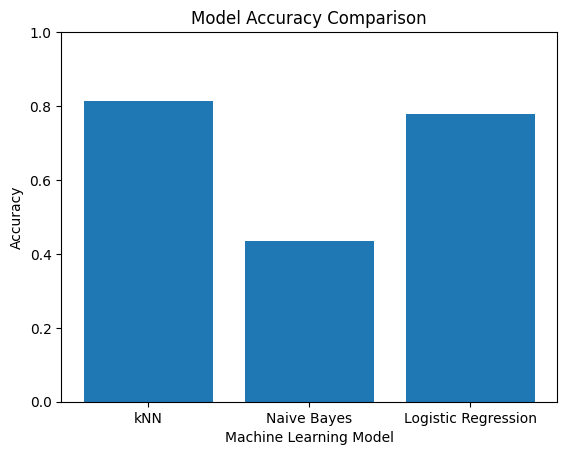

In [47]:
import matplotlib.pyplot as plt

models = ["kNN", "Naive Bayes", "Logistic Regression"]
accuracies = [accuracy_knn, accuracy_nb, accuracy_log]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.show()


### 12.1 Model Performance Comparison

In order to visually compare the predictive performance of the different models, the accuracy scores of the k-Nearest Neighbors, Naive Bayes, and Logistic Regression models are illustrated via the chart above.
The **kNN model is the most suitable model for churn prediction in this dataset**.


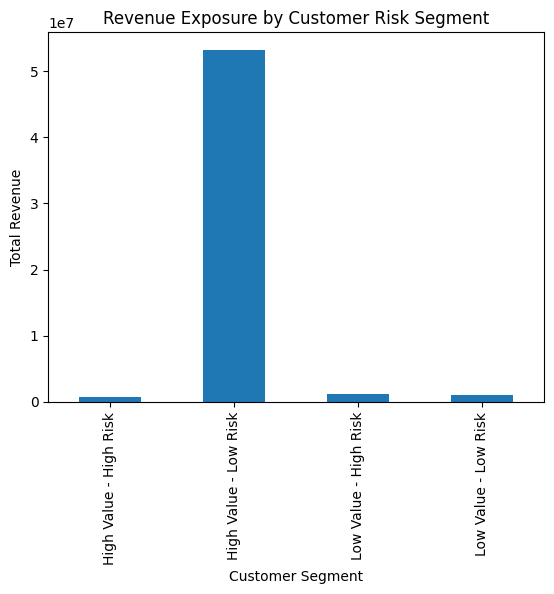

In [48]:
risk_revenue = model_data.groupby("risk_segment")["total_revenue"].sum()

plt.figure()
risk_revenue.plot(kind="bar")

plt.title("Revenue Exposure by Customer Risk Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.show()


### 12.2 Revenue Exposure by Customer Risk Segment

The chart above depicts how the total historical revenue is distributed amongst the various customer risk segments which were identified identified by the churn prediction model. It highlights the financial exposure that can be associated with customers that are both high value as well as predicted to churn, as they represent the most critical group for retention efforts since their departure would result in significant revenue loss. 

By combining machine learning predictions with customer revenue information, the analysis thereby allows the company to employ data-driven driven customer retention strategies, focusing resources on the customer segments that present the greatest financial risk or loss. 
